In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import config
config.conf_matplolib()

In [2]:
hfile = h5py.File("/mnt/pfs/vaishak.p/sims/SpEC/gcc/sonic_new/ligo/post_processing/nbs/processed_waveforms/R114Sur15_waveforms_Lev3/joined/Horizons_Joined.h5")

In [3]:
hfile.keys()

<KeysViewHDF5 ['AhA.dir', 'AhB.dir', 'AhC.dir', 'VersionHist.ver']>

In [4]:
dataA = hfile['AhA.dir']
dataB = hfile['AhB.dir']
dataC = hfile['AhC.dir']

In [5]:
dataA.keys()

<KeysViewHDF5 ['ArealMass.dat', 'ChristodoulouMass.dat', 'CoordCenterInertial.dat', 'CoordSpinChiInertial.dat', 'CoordSpinChiMagInertial.dat', 'DimensionfulInertialCoordSpin.dat', 'DimensionfulInertialCoordSpinMag.dat', 'DimensionfulInertialSpin.dat', 'DimensionfulInertialSpinMag.dat', 'SpinFromShape.dat', 'chiInertial.dat', 'chiMagInertial.dat']>

In [6]:
dataC.keys()

<KeysViewHDF5 ['ArealMass.dat', 'ChristodoulouMass.dat', 'CoordCenterInertial.dat', 'CoordSpinChiInertial.dat', 'CoordSpinChiMagInertial.dat', 'DimensionfulInertialCoordSpin.dat', 'DimensionfulInertialCoordSpinMag.dat', 'DimensionfulInertialSpin.dat', 'DimensionfulInertialSpinMag.dat', 'SpinFromShape.dat', 'chiInertial.dat', 'chiMagInertial.dat']>

In [7]:
massA = 0.567868
massB = 0.473004

In [8]:
amassA = dataA["ArealMass.dat"][...]

In [34]:
xA = dataA['CoordCenterInertial.dat'][...]
chiA = dataA['chiInertial.dat'][...]
chmassA = dataA['ChristodoulouMass.dat'][...]
spinA_mag = dataA["DimensionfulInertialSpinMag.dat"][...]

xB = dataB['CoordCenterInertial.dat'][...]
chiB = dataB['chiInertial.dat'][...]
chmassB = dataB['ChristodoulouMass.dat'][...]
spinB_mag = dataB["DimensionfulInertialSpinMag.dat"][...]

xC = dataC['CoordCenterInertial.dat'][...]
chiC = dataC['chiInertial.dat'][...]

In [39]:
hmassA = np.sqrt( amassA[:, 1]**2 + spinA_mag[:, 1]**2/(4*amassA[:, 1]**2) )

In [40]:
hmassA

array([0.55476734, 0.55476799, 0.55476833, ..., 0.55550477, 0.55582693,
       0.55633431])

In [42]:
chmassA[:, 1]

array([0.55476734, 0.55476799, 0.55476833, ..., 0.55550477, 0.55582693,
       0.55633431])

In [22]:
chmassA

array([[0.00000000e+00, 5.54767344e-01],
       [5.00000000e-01, 5.54767990e-01],
       [1.00000000e+00, 5.54768330e-01],
       ...,
       [5.83950000e+03, 5.55504771e-01],
       [5.84000000e+03, 5.55826931e-01],
       [5.84050000e+03, 5.56334308e-01]])

In [23]:
chmassA.shape

(11682, 2)

(0.0, 5000.0)

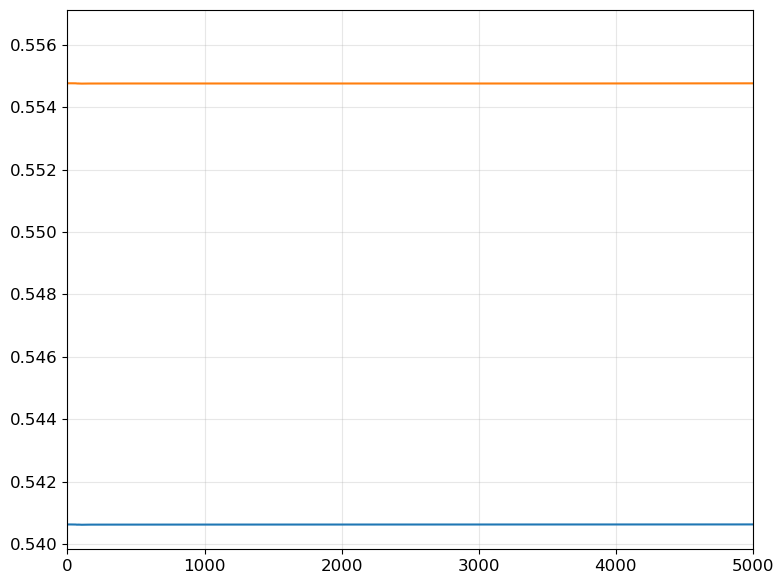

In [25]:
plt.plot(amassA[:, 0], amassA[:, 1])
plt.plot(chmassA[:, 0], chmassA[:, 1])
plt.xlim(0, 5000)


In [30]:
chmass = chmassA + chmassB

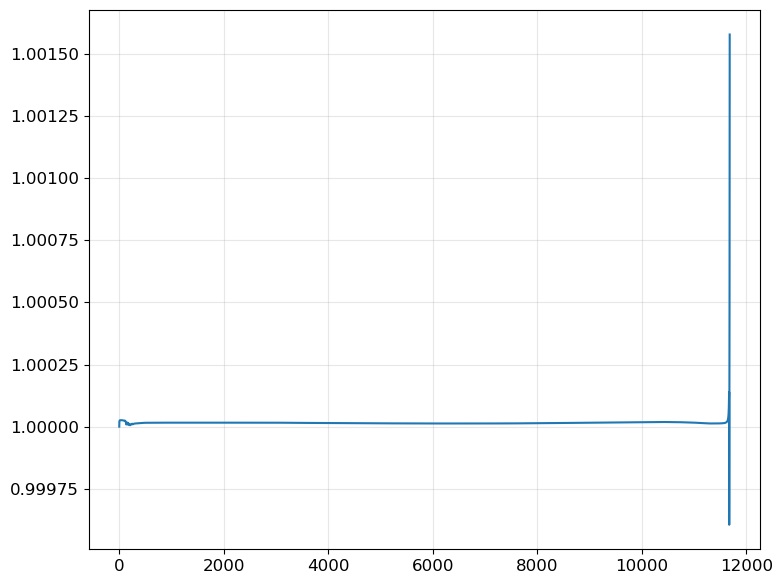

In [31]:
plt.plot(chmass[:, 0], chmass[:, 1])
plt.show()

In [10]:
mass3 = dataC["ChristodoulouMass.dat"][...]

In [16]:
mass3[-1]

array([6.74493463e+03, 9.52580398e-01])

In [9]:
xC[0]

array([ 5.83952147e+03, -1.01252432e-01,  1.33880630e-02, -1.05070935e-01])

In [10]:
chiC[-1], chiC[0]

(array([ 6.74493463e+03, -3.14242271e-02,  6.99165153e-02,  6.60381999e-01]),
 array([ 5.83952147e+03, -6.19812934e-02, -7.65529113e-03,  3.59244241e-01]))

In [11]:
vC = np.diff(xC, axis=0)

In [12]:
vC.shape

(5453, 4)

In [13]:
vmag = np.sqrt(np.sum(vC*vC, axis=1))

In [14]:
vmag.shape

(5453,)

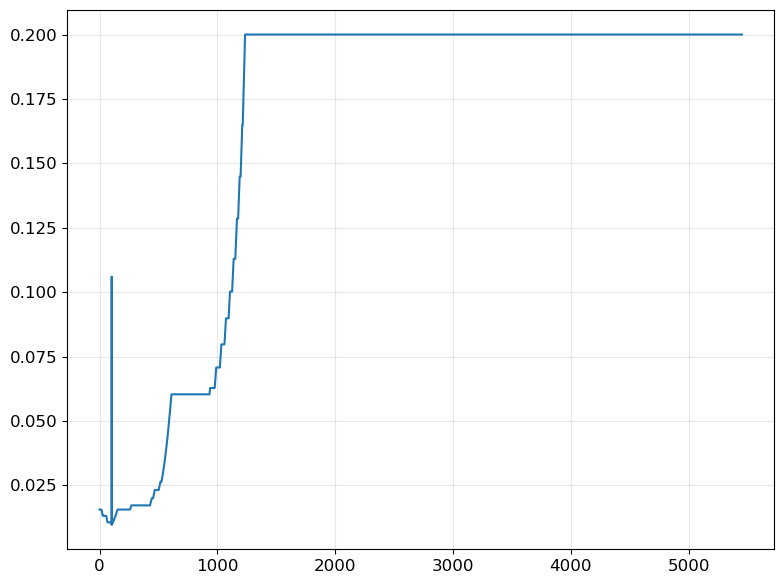

In [15]:
plt.plot(vmag)

In [16]:
vmag[-1]

0.20000172925533244

In [17]:
xA[0]

array([0.00000000e+00, 7.12011024e+00, 6.72557491e-03, 1.23183212e-02])

In [18]:
chiC_f = chiC[-1]
vC_f = vC[-1]

In [19]:

import scri

In [20]:
waveform_modes = scri.SpEC.read_from_h5('/mnt/pfs/vaishak.p/sims/SpEC/gcc/sonic_new/ligo/post_processing/nbs/processed_waveforms/R114Sur15_waveforms_Lev3/extrapolated/rhOverM_Extrapolated_N3_CoM.h5')

In [32]:
waveform_modes.t

array([-226.26246621, -225.21721755, -224.17196889, ..., 6006.8855556 ,
       6006.98555198, 6007.08554836])

In [38]:
from importlib import reload


In [32]:
import sxstools
reload(sxstools)
import sxstools.transforms
reload(sxstools.transforms)

<module 'sxstools.transforms' from '/mnt/pfs/vaishak.p/Projects/Codes/custom_libraries/sxstools/sxstools/transforms.py'>

In [142]:
from sxstools.transforms import transform_coordinate_system

In [130]:
chiA.shape

(11682, 4)

In [131]:
len(waveform_modes.t)

17245

In [132]:
chiC_f, vC_f

(array([ 6.74493463e+03, -3.14242271e-02,  6.99165153e-02,  6.60381999e-01]),
 array([ 1.99999979e-01, -1.25695350e-04, -5.18422734e-05, -8.25613486e-04]))

In [133]:
len(waveform_modes.data.T)

77

In [134]:
chiC_f[1:]

array([-0.03142423,  0.06991652,  0.660382  ])

In [137]:
result = transform_coordinate_system(t_ref=434,
                                     waveform_times=waveform_modes.t,
                                     waveform_modes=waveform_modes.data.T,
                                     horizon_times=xA[:, 0],
                                     xA=xA[:, 1:],
                                     xB=xB[:, 1:],
                                     massA=massA,
                                     massB=massB,
                                     chiA=chiA[:, 1:],
                                     chiB=chiB[:, 1:],
                                     chiC_f=chiC_f[1:],
                                     velC_f=vC_f[1:],
                                     )

Omegahats [0.02979231 0.02945151 0.99912213] [0.03282377 0.03137611 0.99896854]
Lhat and omegahat [0.03149597 0.03053313 0.9990374 ] [0.02979231 0.02945151 0.99912213]
[[-0.05220476  0.0497742   0.66089135]]
[[-0.05220476  0.0497742   0.66089135]]
[[-0.04624686  0.05535374  0.66089135]]
[[-0.04624686  0.05535374  0.66089135]]


In [83]:
result

(array([[ 7.07035474, -0.80634503,  0.23676656],
        [ 7.07584019, -0.75433595,  0.23751498],
        [ 7.08093741, -0.70240478,  0.23828598],
        ...,
        [-0.72767289, -0.71875447,  0.10803003],
        [-0.59514404, -0.7672673 ,  0.11580913],
        [-0.45546549, -0.79488281,  0.12166454]]),
 array([[-8.749924  ,  1.01278222, -0.26503789],
        [-8.75712859,  0.95021543, -0.26779756],
        [-8.76410645,  0.88741665, -0.27033497],
        ...,
        [ 0.86106386,  0.942107  , -0.16158632],
        [ 0.69615969,  0.99446032, -0.16418256],
        [ 0.52350795,  1.02112331, -0.16437672]]),
 array([[ 0.13969037,  0.13919414, -0.39037624],
        [ 0.13962795,  0.13931445, -0.39035171],
        [ 0.13955014,  0.13937461, -0.39035498],
        ...,
        [ 0.10161901, -0.25774994, -0.30932207],
        [ 0.10671909, -0.24839425, -0.30839006],
        [ 0.1098781 , -0.23865395, -0.30570664]]),
 array([[-0.33843657,  0.36133974,  0.51883252],
        [-0.33796276,  0

In [113]:
xA_rot_xyz, xB_rot_xyz, chiA_rot_xyz, chiB_rot_xyz, chiC_f_rot_xyz, velC_f_rot_xyz, waveform_modes_rot_xyz = result

In [114]:
chiC_f_rot_xyz.shape

(3,)

In [86]:
horizon_times = xA[:, 0] 

In [90]:
hidx_ref = np.argmin(abs(horizon_times - 434))

In [115]:
chiA0_t = chiA_rot_xyz[hidx_ref]
chiB0_t = chiB_rot_xyz[hidx_ref]

chiC_t = chiC_f_rot_xyz




In [116]:
chiA0_t, chiB0_t, chiC_f_rot_xyz

(array([ 0.08433322,  0.17266825, -0.39282969]),
 array([-0.44158637,  0.21858152,  0.52099511]),
 array([-0.04624686,  0.05535374,  0.66089135]))

In [118]:
0.05166, 0.16903, -0.4

(0.05166, 0.16903, -0.4)

In [119]:
-0.44702, 0.183, 0.53

(-0.44702, 0.183, 0.53)

In [117]:
chiA[0]

array([ 0.        ,  0.11052468,  0.1421262 , -0.39858056])

In [85]:
xA_rot_xyz

array([[ 7.07035474, -0.80634503,  0.23676656],
       [ 7.07584019, -0.75433595,  0.23751498],
       [ 7.08093741, -0.70240478,  0.23828598],
       ...,
       [-0.72767289, -0.71875447,  0.10803003],
       [-0.59514404, -0.7672673 ,  0.11580913],
       [-0.45546549, -0.79488281,  0.12166454]])

In [72]:
waveform_modes.data.shape

(17245, 77)

In [73]:
waveform_modes.data.T

array([[-7.78346044e-05+2.16788183e-03j, -7.82797086e-05+2.17657774e-03j,
        -7.86150674e-05+2.18523474e-03j, ...,
        -3.25095896e-06+1.46808035e-05j, -3.26589491e-06+1.46429414e-05j,
        -3.27852964e-06+1.46047722e-05j],
       [-2.57408248e-05+1.34905302e-05j, -2.56340076e-05+1.39679546e-05j,
        -2.57339759e-05+1.42067292e-05j, ...,
         1.37620177e-05+1.55547135e-05j,  1.37716056e-05+1.55495735e-05j,
         1.37812421e-05+1.55448898e-05j],
       [ 9.31256705e-05+2.45028008e-06j,  9.37190148e-05+2.46011081e-06j,
         9.42367260e-05+2.43326399e-06j, ...,
         1.50725879e-04-1.15052976e-08j,  1.50695655e-04-1.02084447e-08j,
         1.50665454e-04-8.89274957e-09j],
       ...,
       [ 8.96784354e-08-3.63716083e-09j,  9.04624292e-08-2.51019142e-09j,
         9.12064735e-08-2.59894546e-09j, ...,
         2.52445186e-07-1.29301851e-07j,  2.52431951e-07-1.29264300e-07j,
         2.52415645e-07-1.29226940e-07j],
       [-2.56222515e-08+3.37140342e-09j, -1.

In [97]:
from importlib import reload
import sxstools
reload(sxstools)
import sxstools.transforms
reload(sxstools.transforms)
import sxstools.coordinate_transform
reload(sxstools.coordinate_transform)
from sxstools.coordinate_transform import CoordinateTransform

In [22]:
ctransform = CoordinateTransform(t_ref=434,
                                 waveform_modes=waveform_modes.data.T,
                                 waveform_times=waveform_modes.t,
                                 massA=massA,
                                 massB=massB,
                                 xA=xA,
                                 xB=xB,
                                 chiA=chiA,
                                 chiB=chiB,
                                 chiC_final=chiC_f[1:],
                                 v_kick=vC_f[1:],
                                 normal_direction='Lhat',
                                 )

In [180]:
ctransform.transform()

Omegahats [0.02979231 0.02945151 0.99912213] [0.03282377 0.03137611 0.99896854]
Lhat [0.03149597 0.03053313 0.9990374 ], Omegahat: [0.02979231 0.02945151 0.99912213]


In [177]:
ctransform.transform()

Omegahats [0.02979231 0.02945151 0.99912213] [0.03282377 0.03137611 0.99896854]
Lhat [0.03149597 0.03053313 0.9990374 ], Omegahat: [0.02979231 0.02945151 0.99912213]


In [173]:
ctransform.waveform_modes_rot_z

array([[-7.33259730e-05+2.16637725e-03j, -7.37465835e-05+2.17504782e-03j,
        -7.40583233e-05+2.18369310e-03j, ...,
        -3.18012798e-06+1.39397051e-05j, -3.19556724e-06+1.39017358e-05j,
        -3.20869559e-06+1.38634404e-05j],
       [ 3.45694307e-05+8.04882631e-05j,  3.49059658e-05+8.12293521e-05j,
         3.50394742e-05+8.17319215e-05j, ...,
         8.24941095e-06+1.04225438e-05j,  8.25856938e-06+1.04177580e-05j,
         8.26783956e-06+1.04133458e-05j],
       [ 9.62284378e-05+3.22112431e-06j,  9.68339613e-05+3.25295589e-06j,
         9.73638247e-05+3.24389485e-06j, ...,
         1.52567338e-04-2.30310588e-08j,  1.52536913e-04-2.21957206e-08j,
         1.52506531e-04-2.13178218e-08j],
       ...,
       [ 9.15423634e-08-3.36552597e-09j,  9.04404188e-08-2.58414638e-09j,
         8.74131680e-08-1.13301415e-09j, ...,
         2.58525184e-07-1.21059947e-07j,  2.58511357e-07-1.21041757e-07j,
         2.58494551e-07-1.21024130e-07j],
       [-9.66904999e-09+2.25881243e-09j,  3.

In [78]:
ctransform_fine = CoordinateTransform(t_ref=434,
                                        waveform_modes=waveform_modes.data.T,
                                        waveform_times=waveform_modes.t,
                                        massA=massA,
                                        massB=massB,
                                        xA=xA,
                                        xB=xB,
                                        chiA=chiA,
                                        chiB=chiB,
                                        chiC_final=chiC_f[1:],
                                        v_kick=vC_f[1:],
                                        normal_direction='Lhat',
                                        method='fine'
                                        )

In [79]:
ctransform_fine.transform()

Omegahats [0.02979231 0.02945151 0.99912213] [0.03282377 0.03137611 0.99896854]
Lhat [0.03149908 0.03050667 0.99903811], Omegahat: [0.02979231 0.02945151 0.99912213]


In [55]:
ctransform_fine.Lhat

array([0.03149908, 0.03050667, 0.99903811])

In [56]:
ctransform_fine.chiC_final_rot_xyz

array([[-0.04610072,  0.05549312,  0.66088987]])

In [83]:
ctransform_fine.chiA_ref, ctransform_fine.phi_ref

(array([ 0.0847883 ,  0.17243478, -0.39283429]), 0.11586249314160504)

In [49]:
ctransform_rough = CoordinateTransform(t_ref=434,
                                        waveform_modes=waveform_modes.data.T,
                                        waveform_times=waveform_modes.t,
                                        massA=massA,
                                        massB=massB,
                                        xA=xA,
                                        xB=xB,
                                        chiA=chiA,
                                        chiB=chiB,
                                        chiC_final=chiC_f[1:],
                                        v_kick=vC_f[1:],
                                        normal_direction='Lhat',
                                        method='rough'
                                        )

In [50]:
ctransform_rough.transform()

Omegahats [0.02979231 0.02945151 0.99912213] [0.03282377 0.03137611 0.99896854]
Lhat [0.03149597 0.03053313 0.9990374 ], Omegahat: [0.02979231 0.02945151 0.99912213]


In [51]:
ctransform_rough.Lhat

array([0.03149597, 0.03053313, 0.9990374 ])

In [52]:
ctransform_rough.chiC_final_rot_xyz

array([[-0.04610072,  0.05547551,  0.66089135]])

In [58]:
100*(ctransform_rough.Lhat/ctransform_fine.Lhat - 1)

array([-9.88981141e-03,  8.67346707e-02, -7.10798405e-05])

In [59]:
100*(ctransform_rough.v_kick_rot_xyz/ctransform_fine.v_kick_rot_xyz - 1)

array([[ 2.72912619e-06, -1.49501629e-01,  4.74364124e-05]])

In [64]:
ctransform_rough_omega = CoordinateTransform(t_ref=434,
                                        waveform_modes=waveform_modes.data.T,
                                        waveform_times=waveform_modes.t,
                                        massA=massA,
                                        massB=massB,
                                        xA=xA,
                                        xB=xB,
                                        chiA=chiA,
                                        chiB=chiB,
                                        chiC_final=chiC_f[1:],
                                        v_kick=vC_f[1:],
                                        normal_direction='Omegahat',
                                        method='rough'
                                        )

In [65]:
ctransform_rough_omega.transform()

Omegahats [0.02979231 0.02945151 0.99912213] [0.03282377 0.03137611 0.99896854]
Lhat [0.03149597 0.03053313 0.9990374 ], Omegahat: [0.02979231 0.02945151 0.99912213]


In [66]:
100*(ctransform_rough_omega.Lhat/ctransform_fine.Lhat - 1)

array([-9.88981141e-03,  8.67346707e-02, -7.10798405e-05])

In [67]:
100*(ctransform_rough_omega.v_kick_rot_xyz/ctransform_fine.v_kick_rot_xyz - 1)

array([[ 2.72912619e-06, -1.49501629e-01,  4.74364124e-05]])

In [146]:
from importlib import reload
import sxstools
reload(sxstools)
import sxstools.transforms
reload(sxstools.transforms)
import sxstools.coordinate_transform
reload(sxstools.coordinate_transform)
from sxstools.coordinate_transform import CoordinateTransform
import sxstools.rotations
reload(sxstools.rotations)

<module 'sxstools.rotations' from '/mnt/pfs/vaishak.p/Projects/Codes/custom_libraries/sxstools/sxstools/rotations.py'>

In [152]:
ctransform_rough_2 = CoordinateTransform(t_ref=434,
                                        waveform_modes=waveform_modes.data.T,
                                        waveform_times=waveform_modes.t,
                                        massA=massA,
                                        massB=massB,
                                        xA=xA,
                                        xB=xB,
                                        chiA=chiA,
                                        chiB=chiB,
                                        chiC_final=chiC_f[1:],
                                        v_kick=vC_f[1:],
                                        normal_direction='Omegahat',
                                        method='rough'
                                        )

In [153]:
ctransform_rough_2.transform()

Omegahats [0.02979231 0.02945151 0.99912213] [0.03282377 0.03137611 0.99896854]
Lhat [0.03149597 0.03053313 0.9990374 ], Omegahat: [0.02979231 0.02945151 0.99912213]


chiC_final_rot_z
v_kick_rot_z


In [101]:
ctransform_rough_2.interpolants

{}

In [118]:
ctransform_rough_2.transformed_quantities.keys()

dict_keys(['chiC_final_rot_z', 'v_kick_rot_z', 'xA_rot_z', 'xB_rot_z', 'chiA_rot_z', 'chiB_rot_z'])

In [126]:
ctransform_rough_2.transformed_quantities['chiC_final_rot_z'][0]

array([-0.05220476,  0.0497742 ,  0.66089135])

In [136]:
ctransform_rough_2.reference_parameters

{'massA': 0.567868,
 'massB': 0.473004,
 'chiA': array([ 0.0847883 ,  0.17244525, -0.39282969]),
 'chiB': array([-0.44100838,  0.21974534,  0.52099511]),
 'phi': 0.11586194595432961}

In [137]:
ctransform_rough_2.transformed_quantities['chiC_final_rot_xyz']

array([-0.04610072,  0.05547551,  0.66089135])

In [149]:
ctransform_rough_2.reference_parameters

{'massA': 0.567868,
 'massB': 0.473004,
 'chiA': array([ 0.0847883 ,  0.17243478, -0.39283429]),
 'chiB': array([-0.44100839,  0.21975922,  0.52098925]),
 'chiC_final': array([-0.04610072,  0.05549312,  0.66088987]),
 'v_kick': array([-1.02016872e-04, -1.48030219e-05, -8.30360162e-04]),
 'phi': 0.11586249314160507}

In [154]:
ctransform_rough_2.reference_parameters

{'massA': 0.567868,
 'massB': 0.473004,
 'chiA': array([ 0.0847883 ,  0.17244525, -0.39282969]),
 'chiB': array([-0.44100838,  0.21974534,  0.52099511]),
 'chiC_final': array([-0.04610072,  0.05547551,  0.66089135]),
 'v_kick': array([-1.02016875e-04, -1.47808911e-05, -8.30360556e-04]),
 'phi': 0.11586194595432961}

In [163]:
a = 'Lev2_AB'
a.split('_')[0][3:]

'2'

In [164]:
a = 2.345

In [165]:
b = {}

a:.2f

SyntaxError: invalid decimal literal (3239216517.py, line 3)

In [166]:
round(a, 2)

2.35

In [ ]:
waveform_modes.


WaveformModes(
    t=[-226.262466 -225.217218 -224.171969 ... 6006.885556 6006.985552 6007.085548],
    frame=[],
    data=[[-7.783460e-05+2.167882e-03j -2.574082e-05+1.349053e-05j  9.312567e-05+2.450280e-06j ...  8.967844e-08-3.637161e-09j -2.562225e-08+3.371403e-09j
           -1.229132e-07+1.005491e-08j]
          [-7.827971e-05+2.176578e-03j -2.563401e-05+1.396795e-05j  9.371901e-05+2.460111e-06j ...  9.046243e-08-2.510191e-09j -1.184404e-08+1.326450e-08j
           -1.245302e-07+6.573834e-09j]
          [-7.861507e-05+2.185235e-03j -2.573398e-05+1.420673e-05j  9.423673e-05+2.433264e-06j ...  9.120647e-08-2.598945e-09j  1.799670e-08+2.845499e-09j
           -1.272346e-07+4.076386e-09j]
          ...
          [-3.250959e-06+1.468080e-05j  1.376202e-05+1.555471e-05j  1.507259e-04-1.150530e-08j ...  2.524452e-07-1.293019e-07j -7.468503e-08+3.820229e-09j
           -1.251437e-07+3.830606e-07j]
          [-3.265895e-06+1.464294e-05j  1.377161e-05+1.554957e-05j  1.506957e-04-1.020844e-

In [ ]:
scri.SpEC.file_io.write_to_h5()